# Overview

## Outline and review
1. Setup / boilerplate
    * The inner workings of the replay buffer are not important for this notebook, but it remains here for your curiosity
2. Langevin dynamics: implementation and testing
    * This is what we use to generate samples from the model, and to train negative samples for the model
    * You will use Langevin dynamics on a simple energy surface, and then use it later for training and sampling
    * Langevin dynamics are central to the learning and sampling process of EBMs
3. Generating training data
    * We will use the `data.generate_samples` function create some synthetic, simple training data for our network
4. Setting up the model
    * Our model will be parameterized by a neural network.
    * Basically, data -> NN -> energy. The energy is a potential surface corresponding with dimensionality identical to that of the input (data).
5. Training the neural net
    * Just a simple training loop with some auxiliary code for visualization (and/or debugging)
    * We will be generating samples using the Langevin dynamics function we wrote earlier
6. Sampling from the model
    * With our trained model, we can now (try to) generate realistic samples
7. Fancy plots
    * Visualize the fruits of your labor

## TODO
You will be implementing certain pieces of the training and sampling process, denoted by a "TODO" tag:
1. Adding noise to samples
2. Implementing a Langevin dynamics step
3. Calculating the energy of initial samples
4. Running Langevin dynamics
5. Calculating the energy of final samples
6. Implementing the loss function
7. Running Langevin dynamics inside the training loop
8. Calculating the loss of the NN inside the training loop

Solutions will be in `ebm_tutorial_solutions.ipynb`. If you get stuck for a few minutes, don't be afraid to look at the solution! Just try to think about it for a little bit :)

# Setup

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Set up the replay buffer

In [3]:
class ReplayBuffer():
    def __init__(self, max_size, init_data):
        self.sample_list = init_data
        self.max_size = max_size

    # This starts populated with noise and then is eventually replaced with generated samples
    def add(self, samples):
        self.sample_list = torch.cat([self.sample_list, samples], 0)
        buffer_len = self.sample_list.shape[0]
        if buffer_len > self.max_size:
            self.sample_list = self.sample_list[buffer_len - self.max_size:]

    def sample(self, num_samples, remove_on_sample=True):
        buffer_len = self.sample_list.shape[0]
        sample_count = num_samples if buffer_len > num_samples else buffer_len
        indices = torch.randint(0, buffer_len, (sample_count,))
        samples = self.sample_list[indices]
        if remove_on_sample and buffer_len > sample_count:
            # Create a mask of indices to keep (all indices except the sampled ones)
            mask = torch.ones(buffer_len, dtype=torch.bool, device=self.sample_list.device)
            mask[indices] = False
            # Keep only the non-sampled elements
            self.sample_list = self.sample_list[mask]
            
        return samples


# Langevin dynamics: definition and intuition

### Define energy functions

In [4]:
class QuadraticEnergy1D(torch.nn.Module):
    def forward(self, x):
        return 0.5 * (x ** 2)

class Higgs1D(torch.nn.Module):
    def forward(self, x):
        return 0.01 * ((1.2 * x) ** 2 - 9) ** 2

### Write Langevin step

In [5]:
def sample_langevin(x, model, sample_steps, step_size, noise_scale, return_list=False):
    if return_list:
        sample_list = []
        sample_list.append(x.detach())

    for _ in range(sample_steps):


        ######### TODO: Add noise to the samples ##########
        noise = torch.randn_like(x) * noise_scale
        ###################################################


        energy = model(x)
        # Here we calculate the gradient at the sample point.
        #    "Only inputs" so that only grad wrt x is calculated (and not all remaining vars).
        gradient = torch.autograd.grad(energy.sum(), x, only_inputs=True)[0] 


        ######### TODO: perform the Langevin step ##########
        x = x - gradient * step_size + noise
        ####################################################


        if return_list:
            sample_list.append(x.detach())
    if return_list:
        return sample_list[-1], sample_list
    else:
        # Detach because, when calculating the loss, we do not want to calculate the gradients
        #   through the entire sampling process (at least for now)
        return x.detach()  

There are 3 main sampler hyperparameters: the number of sample steps, the step size, and the noise scale. Try running with the default values, and after that, I recommend you play around with the values to see how the distribution changes. 

Good starting values are `sample_steps=100`, `step_size=0.1`, and `noise_scale=0.5`.

In [ ]:
x_init = torch.rand(1000, 1) * 10 - 5
x_init.requires_grad = True

# E = QuadraticEnergy1D()
E = Higgs1D()


######### TODO: Calculate energy of the initial samples #########
E_init = E(x_init)
#################################################################


######### TODO: perform Langevin sampling to get more realisitc samples ##########
x_sampled = sample_langevin(x_init, E, sample_steps=100, step_size=0.1, noise_scale=0.5)
##################################################################################


########## TODO: Calculate energy of the sampled points ##########
E_sampled = E(x_sampled)
##################################################################

### Plot distributions

Here we are plotting a very simple, 1D energy surface so that we can build some intuition.

This plots the initial distribution of points, the distribution after sampling, and the target distribution as well. The energy function is also overlaid (on its own axis) so you can visualize how the energy transforms into the probability distribution.

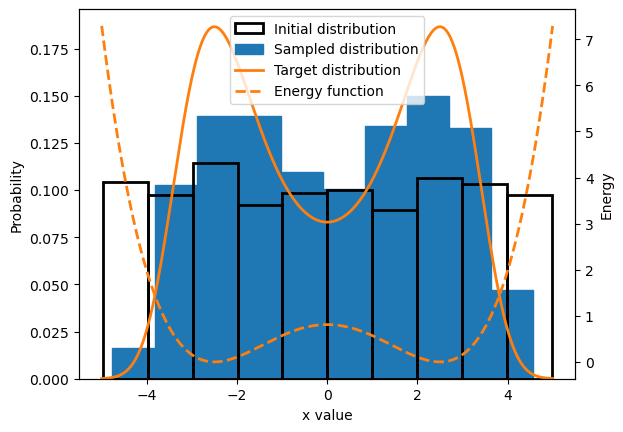

In [7]:
# Compare the initial and sampled distributions, and the energy function
# plot_distributions(x_init, x_sampled, E)
l_plot = -5
r_plot = 5
n_pts = 1000
plt.figure()
ax_orig = plt.gca()
plt.hist(x_init.detach().numpy(), label='Initial distribution',
         fill=False, edgecolor='black', zorder=2, linewidth=2, density = True)
plt.hist(x_sampled.detach().numpy(), label='Sampled distribution',
         fill=True, color='tab:blue', edgecolor='tab:blue', density = True)
probabilities = np.exp(-E(torch.linspace(l_plot, r_plot, n_pts)).detach().numpy())
plt.plot(torch.linspace(l_plot, r_plot, n_pts), probabilities / np.sum(probabilities * (r_plot-l_plot)/n_pts),
        label="Target distribution", color='tab:orange', lw=2)
plt.xlabel('x value')
plt.ylabel('Probability')
ax = plt.gca().twinx()
ax.plot(torch.linspace(l_plot, r_plot, n_pts), E(torch.linspace(l_plot, r_plot, n_pts)).detach().numpy(),
        label="Energy function", color='tab:orange', linestyle='dashed', lw=2)
ax.set_ylabel('Energy')

# ax.set_ylim(0, 1.1)
# Combine legends from both axes
handles1, labels1 = ax_orig.get_legend_handles_labels()
handles2, labels2 = ax.get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2
plt.legend(handles, labels)
# ax.legend()

# Learning E(x): generating training data

Here we generate some synthetic training data. I recommend `2spirals` because the hyperparameters in this notebook are set up for this. For an extra challenge, try the `checkerboard` or some other dataset.

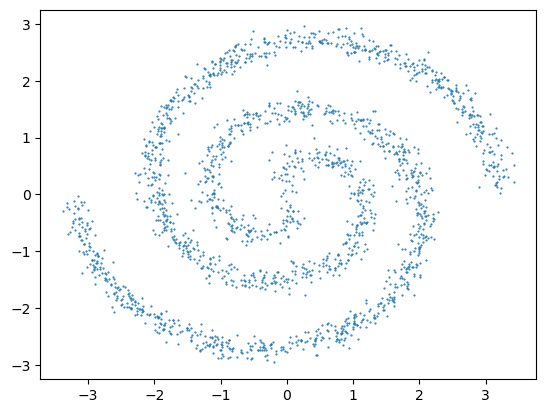

In [8]:
from data import sample_2d_data

# Dataset options are: '8gaussians', '2spirals', 'checkerboard', and 'rings'
# Feel free to try another dataset for a challenge!
samples_2spirals = sample_2d_data(dataset='2spirals', n_samples=2000)
samples_checkerboard = sample_2d_data(dataset='checkerboard', n_samples=2000)
plt.figure()
plt.scatter(samples_2spirals[:, 0], samples_2spirals[:, 1], s=0.3, color='tab:blue')


# plt.figure()
# plt.scatter(samples_checkerboard[:, 0], samples_checkerboard[:, 1], s=0.3, color='tab:blue')

# plt.figure()
# samples_combined = np.concatenate([samples_checkerboard, samples_2spirals], axis=0)
# plt.scatter(samples_combined[:, 0], samples_combined[:, 1], s=0.3, color='tab:blue')

# Learning E(x): setting up the model

Here we're just setting up a basic neural network. No need to fuss with the details unless you want to!

In [9]:
class NeuralNet(torch.nn.Module):
    def __init__(self, depth=8, width=128):
        super(NeuralNet, self).__init__()
        
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(2, width))
        for _ in range(depth - 1):
            self.layers.append(torch.nn.SiLU())
            self.layers.append(torch.nn.Linear(width, width))
        self.layers.append(torch.nn.SiLU())
        self.layers.append(torch.nn.Linear(width, 1))

    def forward(self, x):
        for l in self.layers:
            x = l(x)
        return x.squeeze(-1)  # Squeeze down to 1 dimension (the batch) because only the energy is returned

Create a neural network just for visualization purposes (we will reinitialize later).

In [10]:
nn = NeuralNet(depth=8, width=128)

### Visualize the initial energy on a grid

This is the neural network energy surface before any training. Note that it's pretty smooth. This surface is what will be deformed during the training process.

/home/phil/anaconda3/envs/gr-id-pinn-2/lib/python3.11/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1704987288773/work/aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Text(0, 0.5, 'y value')

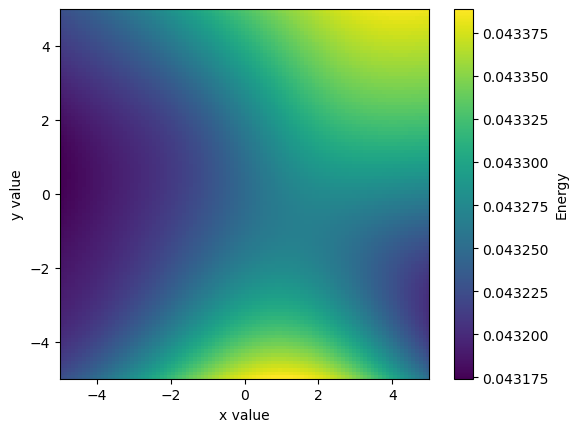

In [11]:
nn_energy_samples = torch.meshgrid(torch.linspace(-5, 5, 100), torch.linspace(-5, 5, 100))
nn_energy_samples = torch.stack(nn_energy_samples, dim=-1).view(-1, 2)
nn_energy = nn(nn_energy_samples).view(100, 100).detach().numpy()
plt.figure()
plt.imshow(nn_energy, extent=(-5, 5, -5, 5), origin='lower', cmap='viridis')
plt.colorbar(label='Energy')
plt.xlabel('x value')
plt.ylabel('y value')

### Define the loss function

Recall that we want to lower energy on real data (positive examples), but increase energy on generated data (negative samples).

In [12]:
########## TODO: write the loss function ##########
# pos_energy and neg_energy have length of the number of samples in the batch
# reg_amount is the amount of regularization to apply to the energy
def loss_func(pos_energy, neg_energy, reg_amount):
    energy_difference = (pos_energy - neg_energy).mean()
    energy_regularization = (pos_energy.square() + neg_energy.square()).mean()
    return energy_difference + reg_amount * energy_regularization
###################################################


### Set our hyperparameters

These are some sane default hyperparameters for training. In my experience, more capacity = better EBM performance, but it may take a long time to train, especially if you do not have a GPU.

In [185]:
# Use GPU?
use_cuda = False

# Optimizer hyperparameters
learning_rate = 1e-3
weight_decay = 0.0
beta1 = 0.0
beta2 = 0.999

# Data handling hyperparameters
batch_size = 100
replay_size = 2000
replay_frac = 0.95

# Training hyperparameters
num_epochs = 101 
reg_amount = 1e-1

# Sampler hyperparameters
sample_steps = 10
step_size = 0.1
noise_scale = 0.1

# Neural network hyperparameters
# I've found that the more parameters, the better
depth = 4
width = 512


### Setup the NN, dataloader, replay buffer, and optimizer

In [ ]:
# Set up neural network and optimizer
# Reinitialize, just to make it easier to change the depth/width
nn = NeuralNet(depth=depth, width=width)
if use_cuda:
    nn = nn.cuda()
optimizer = torch.optim.Adam(nn.parameters(), lr=learning_rate, weight_decay=weight_decay,
                            betas=(beta1, beta2))

# Load the data. Just take the first 2000 samples so that training is faster.
data = samples_2spirals[:2000]
dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(data),
                                             batch_size=batch_size, shuffle=True, num_workers=4)

# Set up the replay buffer ("persistent contrastive divergence")
# Make sure that the data domain is covered by the initial samples!
# Here we're using a gaussian distribution, but you can choose a different initial distribution.
#   It will change training dynamics and the learned energy surface.
def generate_random_samples(num_samples):
    rand_samps = torch.randn(num_samples, data.shape[1]) * 2
    if use_cuda:
        rand_samps = rand_samps.cuda()
    return rand_samps
replay_init_data = generate_random_samples(replay_size)
if use_cuda:
    replay_init_data = replay_init_data.cuda()
replay_buffer = ReplayBuffer(replay_size, replay_init_data)

loss_history = []
pos_x_energy_history = []
neg_x_energy_history = [] 
sample_list_history = []  # To store the Langevin dynamics sample lists for visualization later


# Training the neural network

In [ ]:
# Rerun this multiple times for longer training
for epoch in tqdm(range(num_epochs)):
    for pos_x, in dataloader:  # dataloder returns a tuple
        if use_cuda:
            pos_x = pos_x.cuda()
        batch_size_current = pos_x.shape[0]  # Batch size is not constant; the last batch can be less
        
        # Get some samples from the buffer, depending on the replay fraction
        neg_x_buff = replay_buffer.sample(int(batch_size_current * replay_frac))
        # Set the rest of the negative samples to random noise
        neg_x_rand = generate_random_samples(batch_size_current - neg_x_buff.shape[0])
        # Combine them
        neg_x = torch.concatenate([neg_x_buff, neg_x_rand], axis=0)
        neg_x.requires_grad_(True)  # We'll want to be able to compute the local energy surface gradient 
                                    #   with respect to the samples during Langevin dynamics
        if use_cuda:
            neg_x = neg_x.cuda()
 

        ########## TODO: perform the Langevin MCMC steps ##########
        # Use return_list = True so we can plot trajectories later
        neg_x, sample_list = sample_langevin(neg_x, nn, sample_steps, step_size, noise_scale, return_list=True)
        ###########################################################


        sample_list_history.append(sample_list)  # Store the sample list for visualization later
        neg_x.requires_grad_(True)  # We'll want to calculate the loss gradient with respect to the samples
        replay_buffer.add(neg_x)  # Add the new samples to the replay buffer to be recalled later
        

        ########## TODO: Compute the loss ##########
        pos_energy = nn(pos_x)
        neg_energy = nn(neg_x)
        loss = loss_func(pos_energy, neg_energy, reg_amount)
        ############################################


        # NN update steps
        optimizer.zero_grad()
        loss.backward()
        # Print the maximum gradient norm for diagnostic purposes (to see if gradients are exploding)
        # if epoch % 10 == 0:
            # max_grad_norm = max(p.grad.norm().item() for p in nn.parameters() if p.grad is not None)
            # print(f"Max gradient norm: {max_grad_norm:.4f}")
            # Print max paramter values for diagnostic purposes (to see if parameters are exploding)
            # max_param_value = max(p.abs().max().item() for p in nn.parameters())
            # print(f"Max parameter value: {max_param_value:.4f}")
        # Clip the gradients to prevent them from getting too large (which can cause instabilities)
        torch.nn.utils.clip_grad_norm_(nn.parameters(), max_norm=1e0)
        optimizer.step()
        # Log the energy and loss for diagnostic purposes
        loss_history.append(loss.item())
        pos_x_energy_history.append(pos_energy.mean().item())
        neg_x_energy_history.append(neg_energy.mean().item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Pos Energy: {pos_energy.mean().item():.4f}, "\
              f"Neg Energy: {neg_energy.mean().item():.4f}")



  1%|          | 1/101 [00:00<01:09,  1.44it/s]

Epoch 0, Loss: -0.0094, Pos Energy: -0.0197, Neg Energy: -0.0021


 11%|█         | 11/101 [00:08<01:08,  1.31it/s]

Epoch 10, Loss: -0.0004, Pos Energy: -0.0186, Neg Energy: -0.0175


 21%|██        | 21/101 [00:15<00:59,  1.33it/s]

...

Epoch 80, Loss: 0.0093, Pos Energy: -0.0262, Neg Energy: -0.0345


 90%|█████████ | 91/101 [01:07<00:07,  1.36it/s]

Epoch 90, Loss: -0.0097, Pos Energy: -0.0057, Neg Energy: 0.0045


100%|██████████| 101/101 [01:14<00:00,  1.35it/s]

Epoch 100, Loss: -0.0202, Pos Energy: 0.0159, Neg Energy: 0.0394


Visualize the energy surface (colorbar) along with some particle trajectories (in red) and original data in white.

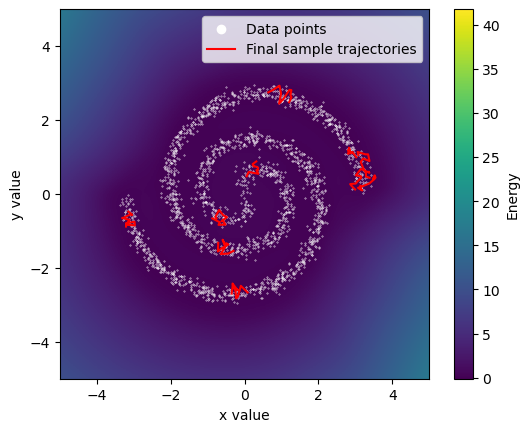

In [188]:
grid_samples = torch.meshgrid(torch.linspace(-10, 10, 250), torch.linspace(-10, 10, 250))
grid_samples = torch.stack(grid_samples, dim=-1).view(-1, 2)
if use_cuda:
    grid_samples = grid_samples.cuda()
nn_energy = nn(grid_samples).reshape(250, 250).detach().cpu().numpy().T

sample_list = sample_list_history[-1]  # Get the sample list from the last batch of the last epoch
np_samples = np.array([s.detach().cpu().numpy() for s in sample_list])

plt.figure() 
plt.imshow(nn_energy, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar(label='Energy')

plt.scatter(samples_2spirals[:, 0], samples_2spirals[:, 1], s=0.1, color='white')
plt.scatter([], [], color='white', label='Data points')  # Dummy scatter for legend
for i in range(10):
    plt.plot(np_samples[:, i, 0], np_samples[:, i, 1], linestyle='-', color='red', label='Final sample trajectories' if i == 0 else None)

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xlabel('x value')
plt.ylabel('y value')
plt.legend()
plt.show()

Plot a slice of the energy profile at y=0. What happens when particles sample outside of the data domain?

Text(0.5, 1.0, 'Energy: x profile at y=0')

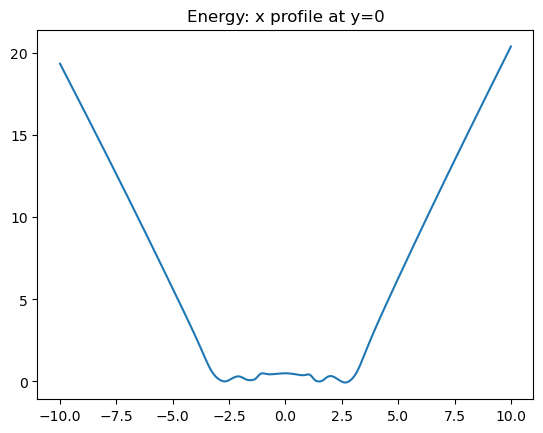

In [189]:
plt.figure()
plt.plot(np.linspace(-10, 10, 250), nn_energy[:,125])
plt.title('Energy: x profile at y=0')

Plot of the loss. Note that it doesn't decrease like a typical discriminitive lose function! In general I've found the total loss to be difficult to interpret.

Text(0, 0.5, 'Loss')

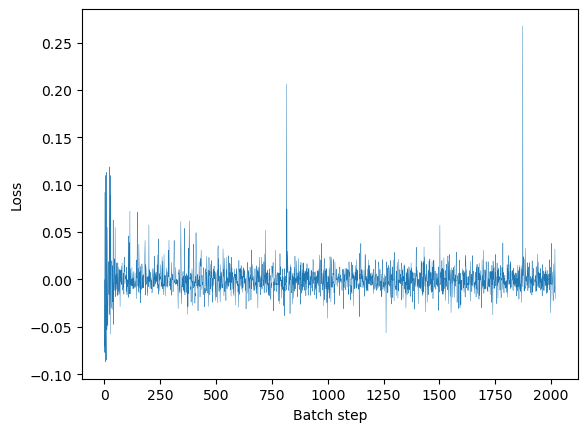

In [190]:
plt.figure()
plt.plot(loss_history, label='Loss', lw=0.3)
plt.xlabel('Batch step')
plt.ylabel('Loss')

The relative energies of the positive and negative samples is one of the most important diagnostics when training EBMs. If the sampler is failing, then the energies will diverge. If training is going well, negative samples usually having slightly higher energies and ocassionally have lower energy than the positive examples.

Text(0, 0.5, 'Energy')

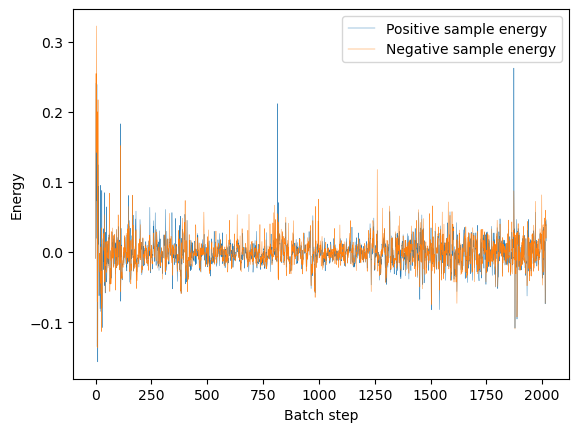

In [191]:
plt.figure()
plt.plot(pos_x_energy_history, label='Positive sample energy', lw=0.3)
plt.plot(neg_x_energy_history, label='Negative sample energy', lw=0.3)
# plt.ylim(-1/reg_amount, 1/reg_amount)
plt.legend()
plt.xlabel('Batch step')
plt.ylabel('Energy')

# Sampling from the learned model

Here we generate some initial ranodm data (same distribution used to train the model) and run them through Langevin dynamics using the learned energy function.

In [192]:
unconditional_samples = generate_random_samples(1000).requires_grad_(True)
unconditional_samples, uncond_list = sample_langevin(unconditional_samples, nn, sample_steps=sample_steps*20, step_size=step_size, noise_scale=noise_scale, return_list=True)

If training went well, then the learned distribution should match the training data.

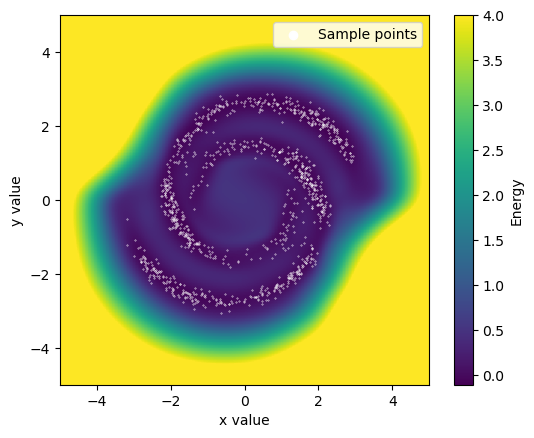

In [193]:
plt.figure() 
# You can more easily see the energy surface by using the "vmax=4" argument, or taking the log of nn_energy
plt.imshow(nn_energy, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis', vmax=4)
plt.colorbar(label='Energy')

plt.scatter(uncond_list[-1][:, 0], uncond_list[-1][:, 1], s=0.1, color='white')
plt.scatter([], [], color='white', label='Sample points')  # Dummy scatter for legend
# for i in range(10):
#     plt.plot(np_samples[:, i, 0], np_samples[:, i, 1], linestyle='-', color='red', label='Final sample trajectories' if i == 0 else None)

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xlabel('x value')
plt.ylabel('y value')
plt.legend()
plt.show()

# Conditional sampling

... if you want a challenge. You will need to sample from just a small slice (or, say, Gaussian) on one axis of the learned energy function. No solution provided, and you'll need to do the sampling and visualization yourself. Good luck!

In [ ]:
class CondModel():
    def __init__(self, nn):
        self.nn = nn

    # x_cond_val is the position to condition on, and x_cond_dim is the dimension to constrain
    def cond_energy(self, x_cond_val, x_cond_dim):
        ## Implement an energy function to sample from a conditional distribution
        ## I'd recommend a quadratic distance function
        ### TODO ###
        ############
        pass


    def forward(self, x, x_cond_val, x_cond_dim):
        model_energy = self.nn(x)
        cond_energy = self.cond_energy(x_cond_val, x_cond_dim)
        
        return model_energy + cond_energy